In [51]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [52]:
tips=sns.load_dataset("tips")
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


# Task: **01**

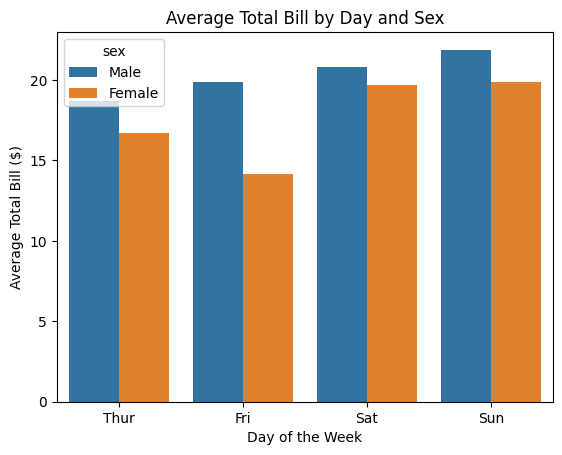

In [56]:
sns.barplot(data=tips, x="day", y="total_bill", hue="sex", errorbar=None)
plt.title("Average Total Bill by Day and Sex")
plt.xlabel("Day of the Week")
plt.ylabel("Average Total Bill")
plt.show()

# **Task: 02**

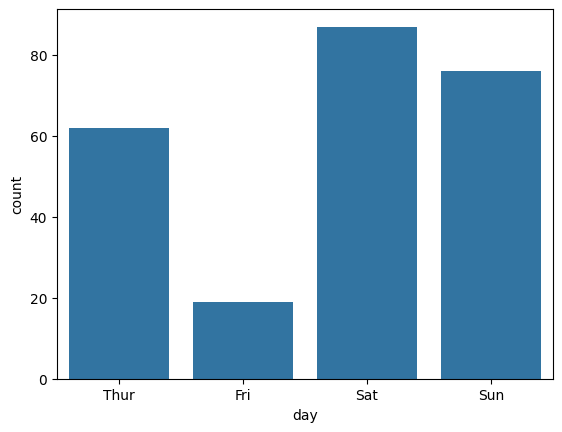

In [17]:
sns.countplot(x="day", data=tips)
plt.show()

# Task: **03**

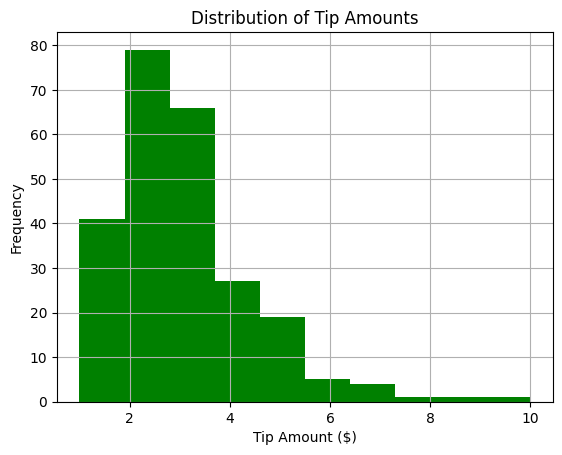

In [18]:
tips['tip'].hist(bins=10,color='green')
plt.xlabel('Tip Amount ($)')
plt.ylabel('Frequency')
plt.title('Distribution of Tip Amounts')
plt.show()

# Task: **04**

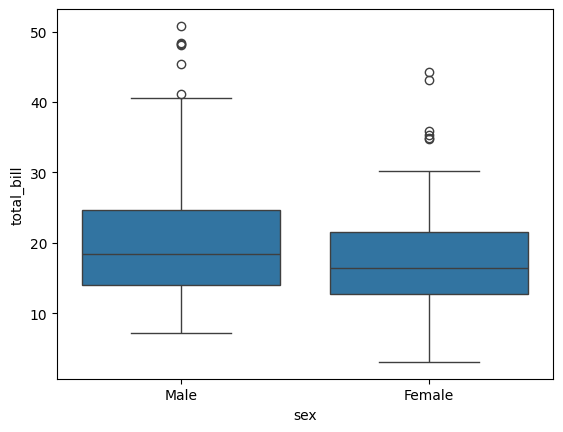

In [19]:
sns.boxplot(data=tips, x="sex", y="total_bill")
plt.show()

About 4 outlier points liew beyond the whiskers in male category, and about 5 points lies beyond the whisker in female category for the total bill.

# Task: **05**

In [32]:
Q1 = tips['total_bill'].quantile(0.25)
Q3 = tips['total_bill'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = tips[(tips['total_bill']<lower)|(tips['total_bill']>upper)]
print(len(outliers))

9


Yes the amount of outliers i have counted matches exactly with the outliers found through interquartile range.

# Task: **06**

In [25]:
tips['total_bill'] = stats.zscore(tips['total_bill'])
outliers_z =tips[tips['total_bill'].abs()>3]
print(len(outliers_z))

4


The ouliers given by z scores are 4 where as exact number of outliers are 9 which is because skewness of data and the concept that the z scores gives us approximate number of outliers, where as the IQR gives us the exact number of outliers. Also the z scores relies fully on mean and standard deviation which is not accurate for skewe dataset, but the IQR uses 25th and 75th percentile that is exactly the reason it gives accurate outliers.

# Task: **07**

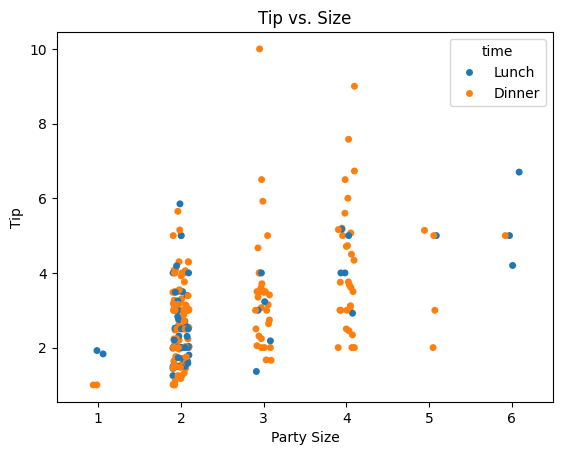

In [29]:
sns.stripplot(data=tips, x="size", y="tip", hue="time")
plt.title("Tip vs. Size")
plt.xlabel("Party Size")
plt.ylabel("Tip")
plt.show()

The relationship apears to be slightly positive and none as with x axis the tip increase for some but may remain same.

# Task: **08**

/tmp/ipykernel_724/1505132496.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total_bill_perdayseries=tips.groupby('day')['total_bill'].mean()


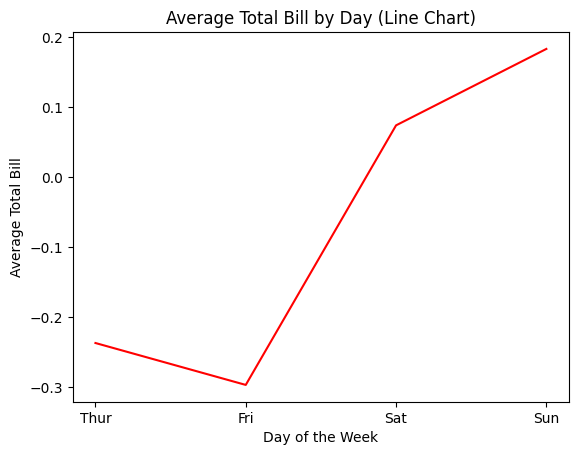

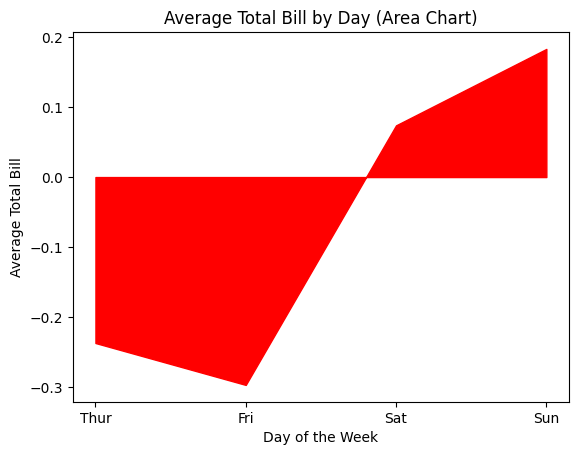

In [47]:
day_order=['Thur','Fri','Sat','Sun']
total_bill_perdayseries=tips.groupby('day')['total_bill'].mean()
total_bill_perdayordered=total_bill_perdayseries.reindex(day_order)

plt.plot(total_bill_perdayordered.index,total_bill_perdayordered.values,color='red',label='Average Total Bill')
plt.title('Average Total Bill by Day (Line Chart)')
plt.xlabel('Day of the Week')
plt.ylabel('Average Total Bill')
plt.show()

plt.fill_between(total_bill_perdayordered.index,total_bill_perdayordered.values,color='red',label='Average Total Bill Area')
plt.title('Average Total Bill by Day (Area Chart)')
plt.xlabel('Day of the Week')
plt.ylabel('Average Total Bill')
plt.show()

Line chart offers clean perception of the average bill per day of the week whereas the area chart gives us the approximate idea of the average bill per day.

# **Task: 09**

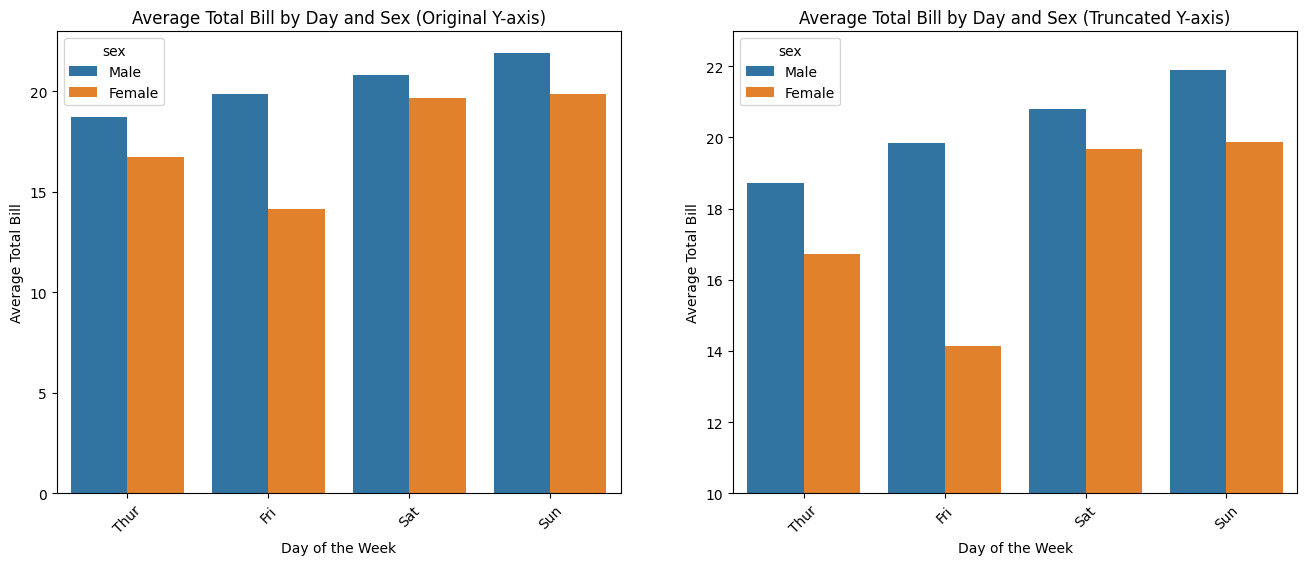

In [60]:
fig,axes=plt.subplots(1,2,figsize=(16,6))
sns.barplot(data=tips,x="day",y="total_bill",hue="sex",errorbar=None,ax=axes[0])
axes[0].set_title("Average Total Bill by Day and Sex (Original Y-axis)")
axes[0].set_xlabel("Day of the Week")
axes[0].set_ylabel("Average Total Bill")
axes[0].tick_params(axis='x',rotation=45)

sns.barplot(data=tips, x="day",y="total_bill",hue="sex",errorbar=None,ax=axes[1])
axes[1].set_title("Average Total Bill by Day and Sex (Truncated Y-axis)")
axes[1].set_xlabel("Day of the Week")
axes[1].set_ylabel("Average Total Bill")
axes[1].set_ylim(bottom=10)
axes[1].tick_params(axis='x',rotation=45)

plt.show()

The truncation of  axis with 10 dollar bill makes the values more exxagerated and more approximated rather than the exact output of data size. And it is unauthorized way of different size.